In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import f

In [6]:
df = pd.read_csv("data/sleep.csv")
df.sample(5)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
95,96,Female,36,Accountant,7.1,8,60,4,Normal,115/75,68,7000,NaN
203,204,Male,43,Engineer,6.9,6,47,7,Normal Weight,117/76,69,6800,NaN
241,242,Male,44,Salesperson,6.3,6,45,7,Overweight,130/85,72,6000,Insomnia
277,278,Male,49,Doctor,8.1,9,85,3,Obese,139/91,86,3700,Sleep Apnea
336,337,Female,54,Engineer,8.4,9,30,3,Normal,125/80,65,5000,NaN


In [7]:
X = df[['Sleep Duration']]
y = df['Stress Level']

Выбраны зависимости уровень стресса от продолжительности сна

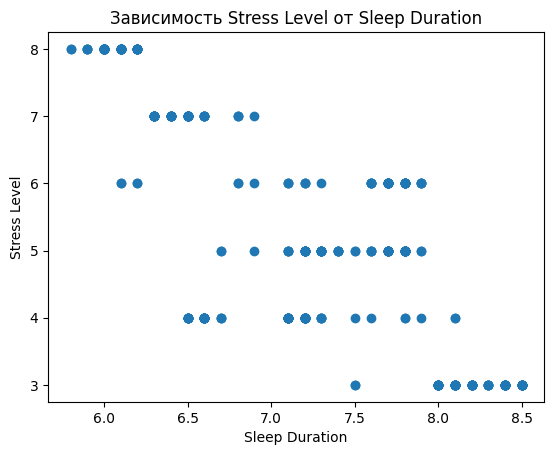

In [8]:
plt.scatter(X, y)
plt.xlabel("Sleep Duration")
plt.ylabel("Stress Level")
plt.title("Зависимость Stress Level от Sleep Duration")
plt.show()

Визуализизирование зависимости уровня стресса от продолжительности сна. На данном этапе проглядывается линейная зависимость

Введем для модели гипотезы H0 и H1
H0 - коэффициент при Sleep Duration равен 0, то есть продолжительность сна не влияет на уровень стресса.
H1 - коэффициент при Sleep Duration не равен 0, то есть продолжительность сна влияет на уровень стресса.
Здесь `p-value` показывает вероятность получить такие данные, если H0 верна. Если `p-value` маленькое, H0 отвергается.

In [9]:
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())
a = model.params["const"]
b = model.params["Sleep Duration"]
print("Уравнение регрессии:")
print("y =", round(a, 2), "+", round(b, 2), "* x")

                            OLS Regression Results                            
Dep. Variable:           Stress Level   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     715.0
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           1.24e-88
Time:                        15:59:53   Log-Likelihood:                -544.18
No. Observations:                 374   AIC:                             1092.
Df Residuals:                     372   BIC:                             1100.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             18.2855      0.485     37.

Уравнение регрессии:
y = 18.29 + -1.81 * x

In [10]:
r2 = model.rsquared
r2_adj = model.rsquared_adj
sigma2 = model.scale

print("R^2 =", r2)
print("Adjusted R^2 =", r2_adj)
print("Остаточная дисперсия =", sigma2)

R^2 = 0.6577583517744219
Adjusted R^2 = 0.6568383473437079
Остаточная дисперсия = 1.0805968618762924


R^2 = 0.658 означает, что модель подогнанна качественно.


In [11]:
print(model.pvalues)

const             5.259017e-129
Sleep Duration     1.237808e-88
dtype: float64


Оба значения близки к нулю, от сюда можно сделать вывод, что H0 будет отвергнута и можно гворить о принятии H1, т.е. продолжительность сна влияет на уровень стресса

Для полученной модели

H0: линейная связь между x и y отсутствует

H1: линейная связь есть

Prob (F-statistic):	1.24e-88 -- вероятность того, что H0 стремится к нулю, поэтому полученное уравнение описывает линейную связь между вектором признаков и таргетом.

In [12]:
print(model.summary().tables[1])

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             18.2855      0.485     37.667      0.000      17.331      19.240
Sleep Duration    -1.8088      0.068    -26.739      0.000      -1.942      -1.676


p-value коэффициентов стремятся к 0, поэтому они значимы.

Модель показывает значимую отрицательную связь между продолжительностью сна и уровнем стресса

ShapiroResult(statistic=np.float64(0.9509469243811842), pvalue=np.float64(8.107748758406985e-10))


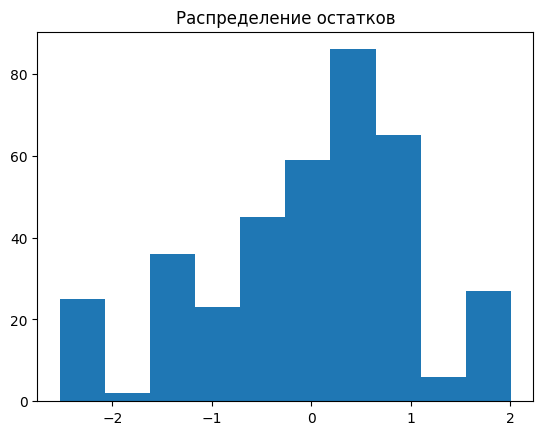

In [13]:
from scipy import stats
residuals = model.resid
print(stats.shapiro(residuals))
plt.hist(residuals)
plt.title("Распределение остатков")
plt.show()

График хоть и выглядит примерно как "колокол", однако заметно сразу, что распределение не "гладкое" и не равномерное. Это означает что остатки не полностью нормальны и модель скорее всего нарушает допущения OLS.

По  гистограмме можно сказать, что нормальность остатков сомнительная, т.е. модель может быть неидеальной

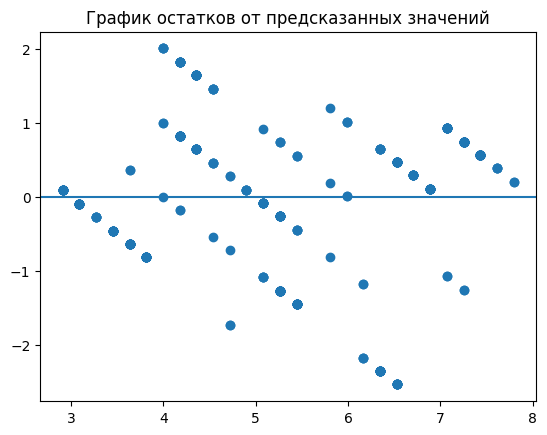

In [14]:
plt.scatter(model.fittedvalues, residuals)
plt.title("График остатков от предсказанных значений")
plt.axhline(0)
plt.show()

По графику видно, что остатки не разбросаны случайно вокруг нуля. Можно сделать вывод, что модель плохо описывает зависимость.

In [15]:
durbin_watson(residuals)

np.float64(0.8043045731764902)

Математическое ожидание остатков

In [16]:
residuals = model.resid
mean = residuals.mean()
std = residuals.std()
print(f"t рассчетное = {mean / std * np.sqrt(len(residuals))}")
print(f"t табличное = {stats.t.ppf(1 - 0.05 / 2, len(residuals))}")

t рассчетное = -1.1006921944486503e-13
t табличное = 1.9663271832585472


t рассчетное меньше табличного, H0 принимается -- мат. ожидание остатков равно 0.

Коэффицент `durbin_watson` < 2 говорит нам о зависимости остатков модели, о положительности автокорреляции. Так как наше значение `durbin_watson` близко к нулю, можно говорить даже о сильной зависимости остатков. Однако, опираясь на утверждения выше, это может свидетельствовать о положительной автокорреляции остатков

In [17]:
bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

{'Lagrange multiplier statistic': np.float64(2.0729046265460864), 'p-value': np.float64(0.14993572744171313), 'f-value': np.float64(2.0733109543978148), 'f p-value': np.float64(0.1507367987731208)}


H0 - дисперсия остатков постоянна (гомоскедастичность)

H1 - дисперсия остатков не постоянна (гетероскедастичность)

В результате теста Breusch-Pagan p-value = 0.1499, что больше обычного уровня значимости 0.05. Следовательно, статистически значимых оснований отвергать H0 нет, и явных признаков гетероскедастичности в остатках не обнаружено.

In [18]:
durbin_watson(model.resid)

np.float64(0.8043045731764902)

Значение 0.8043 говорит о том, что остатки сильно автокоррелированы, соседние ошибки похожи друг на друга и это нарушение допущения OLS об независимости остатков.

In [19]:
stats.shapiro(residuals)

ShapiroResult(statistic=np.float64(0.9509469243811842), pvalue=np.float64(8.107748758406985e-10))

H0 - остатки нормальны

H1 - остатки не нормальны

Поскольку pvalue почти ноль, H0 отвергается. Это значит, что остатки не выглядят нормально, и это ещё одна причина считать, что модель нарушает допущения OLS.

MAE: 0.8219176872816336


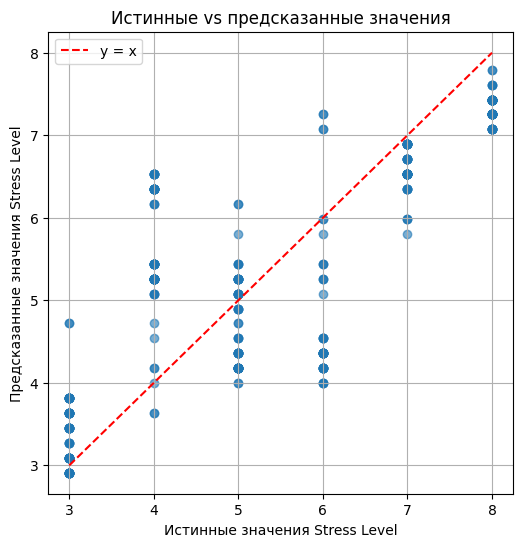

In [20]:
test = X_const.copy()
test['pred'] = model.predict(test)
mae = np.mean(np.abs(y - test['pred']))
print("MAE:", mae)

plt.figure(figsize=(6, 6))
plt.scatter(y, test['pred'], alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='y = x')
plt.xlabel('Истинные значения Stress Level')
plt.ylabel('Предсказанные значения Stress Level')
plt.title('Истинные vs предсказанные значения')
plt.legend()
plt.grid(True)
plt.show()

MAE = 0.8219 это средняя абсолютная ошибка модели, т.е. в среднем прогноз Stress Level отличается от реального значения примерно на 0.82 единицы. Ошибку 0.82 можно считать относительно невысокой. При этом этот показатель получен на тех же данных, на которых модель обучалась.

### Вывод:
Качество подгонки уравнения хорошее, линейная связь между признаками и целевой переменной присутствует, все коэффициенты регрессии значимы. В остатках присутствует положительная автокорреляция, остатки не имеют случайный характер и распределены не нормально. Их дисперсия гомоскедастичная, мат. ожидание равно нулю.